# Лабораторная работа №1 — детекция объектов без YOLO

**Модель:** Faster R-CNN ResNet-50 FPN с COCO-весами.  
Ноутбук считывает изображение, преобразует его в RGB-тензор, запускает инференс и рисует детекции на исходной фотографии.

## 1. Подготовка окружения

In [1]:
!if [ -d /content/mii-lab1/.git ]; then cd /content/mii-lab1 && git pull --ff-only; else git clone -q https://github.com/A-m-u-r/mii-lab1.git /content/mii-lab1; fi
%cd /content/mii-lab1
!apt-get -qq update && apt-get -qq install -y fonts-dejavu-core
!pip -q install -r requirements-lab1.txt
!git rev-parse --short HEAD

/content/mii-lab1
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-dejavu-mono.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-mono_2.37-8_all.deb ...
Unpacking fonts-dejavu-mono (2.37-8) ...
Selecting previously unselected package fonts-dejavu-core.
Preparing to unpack .../fonts-dejavu-core_2.37-8_all.deb ...
Unpacking fonts-dejavu-core (2.37-8) ...
Setting up fonts-dejavu-mono (2.37-8) ...
Setting up fonts-dejavu-core (2.37-8) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
1525450


## 2. Полный исходный код



In [2]:
from IPython.display import Code, display

display(Code(filename='lab1_faster_rcnn.py', language='python'))

"""Лабораторная работа №1: детекция объектов Faster R-CNN (не YOLO)."""

import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Mapping, Sequence


@dataclass(frozen=True)
class Detection:
    """Одна детекция в координатах исходного изображения (x1, y1, x2, y2)."""

    box: tuple[int, int, int, int]
    label: str
    score: float


RUSSIAN_LABELS = {
    "person": "человек",
    "bicycle": "велосипед",
    "car": "автомобиль",
    "motorcycle": "мотоцикл",
    "bus": "автобус",
    "truck": "грузовик",
    "bird": "птица",
    "cat": "кошка",
    "dog": "собака",
    "backpack": "рюкзак",
    "umbrella": "зонт",
    "handbag": "сумка",
    "tie": "галстук",
    "suitcase": "чемодан",
    "bottle": "бутылка",
    "cup": "чашка",
    "bowl": "миска",
    "chair": "стул",
    "couch": "диван",
    "dining table": "обеденный стол",
    "potted plant": "растение",
    "tv": "телевизор",
    "laptop": "ноутбук",
    "mouse": "мышь",
    "remote": "пульт",
    "keyboard": "клавиатура",
    "cell phone": "телефон",
    "book": "книга",
    "clock": "часы",
    "vase": "ваза",
}


def translate_label(label: str) -> str:
    """Возвращает русское название распространённого COCO-класса."""
    return RUSSIAN_LABELS.get(label, label)


def label_font_size(image_size: tuple[int, int]) -> int:
    """Подбирает читаемый размер подписи относительно меньшей стороны изображения."""
    return max(16, min(28, round(min(image_size) * 0.022)))


def load_label_font(font_size: int, image_font: Any = None) -> Any:
    """Загружает шрифт с кириллицей в Colab, Windows или локальном окружении."""
    if image_font is None:
        from PIL import ImageFont

        image_font = ImageFont

    font_paths = (
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "C:/Windows/Fonts/arialbd.ttf",
        "DejaVuSans-Bold.ttf",
        "arialbd.ttf",
        "arial.ttf",
    )
    for font_path in font_paths:
        try:
            return image_font.truetype(font_path, font_size)
        except OSError:
            continue
    return image_font.load_default()


def _as_list(value: Any) -> list[Any]:
    """Преобразует список, NumPy-массив или Tensor в обычный Python-список."""
    return value.tolist() if hasattr(value, "tolist") else list(value)


def filter_predictions(
    prediction: Mapping[str, Any],
    label_names: Sequence[str],
    score_threshold: float,
) -> list[Detection]:
    """Отбрасывает слабые предсказания Faster R-CNN и добавляет названия классов."""
    boxes = _as_list(prediction["boxes"])
    labels = _as_list(prediction["labels"])
    scores = _as_list(prediction["scores"])

    detections = []
    for box, label_index, score in zip(boxes, labels, scores):
        score = float(score)
        if score < score_threshold:
            continue
        x1, y1, x2, y2 = (round(float(coordinate)) for coordinate in box)
        label_index = int(label_index)
        label = label_names[label_index] if label_index < len(label_names) else f"class_{label_index}"
        detections.append(Detection((x1, y1, x2, y2), label, score))
    return detections


def keep_labels(detections: Sequence[Detection], allowed_labels: set[str]) -> list[Detection]:
    """Оставляет детекции только заданных классов."""
    return [detection for detection in detections if detection.label in allowed_labels]


def draw_detections(image: Any, detections: Sequence[Detection]) -> Any:
    """Рисует красные рамки и читаемые подписи на копии изображения."""
    from PIL import ImageDraw

    annotated = image.copy()
    painter = ImageDraw.Draw(annotated)
    font_size = label_font_size(annotated.size)
    font = load_label_font(font_size)

    color = (220, 38, 38)
    line_width = max(3, font_size // 12)
    for detection in detections:
        x1, y1, x2, y2 = detection.box
        painter.rectangle((x1, y1, x2, y2), outline=color, width=line_width)
        label_text = f"{translate_label(detection.lab

## 3. Загрузка исходного изображения

In [3]:
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))
print(f'Загружено: {image_path}')

Saving photo_2025-04-07_16-23-06.jpg to photo_2025-04-07_16-23-06.jpg
Загружено: photo_2025-04-07_16-23-06.jpg


## 4. Загрузка модели и препроцессинг

`preprocess_image` переводит изображение в RGB и float-тензор `[C, H, W]` в диапазоне `[0, 1]`.

In [4]:
import importlib

import torch
from PIL import Image

import lab1_faster_rcnn
importlib.reload(lab1_faster_rcnn)
from lab1_faster_rcnn import (
    draw_detections,
    load_detector,
    run_inference,
)

font = lab1_faster_rcnn.load_label_font(20)
font_path = getattr(font, 'path', '')
assert 'DejaVuSans' in str(font_path), f'Не найден шрифт с кириллицей: {font_path}'
print(f'Шрифт подписей: {font_path}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector, coco_labels = load_detector(device)
print(f'Устройство: {device}')

Шрифт подписей: /usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 115MB/s]


Устройство: cpu


## 5. Инференс и визуализация детекций

Найдено объектов: 34
1. cup: 1.00, box=(421, 792, 478, 871)
2. person: 1.00, box=(38, 303, 249, 740)
3. person: 1.00, box=(719, 451, 887, 929)
4. cell phone: 0.99, box=(512, 809, 614, 840)
5. tie: 0.99, box=(169, 404, 208, 574)
6. person: 0.99, box=(466, 326, 603, 610)
7. person: 0.99, box=(373, 448, 538, 634)
8. person: 0.98, box=(873, 485, 1107, 950)
9. tie: 0.98, box=(320, 396, 339, 452)
10. potted plant: 0.98, box=(1152, 447, 1215, 525)
11. cell phone: 0.98, box=(482, 847, 557, 931)
12. cell phone: 0.98, box=(436, 841, 575, 953)
13. person: 0.97, box=(1016, 355, 1130, 609)
14. tie: 0.96, box=(266, 420, 290, 545)
15. person: 0.95, box=(714, 326, 858, 539)
16. person: 0.95, box=(223, 336, 339, 602)
17. person: 0.94, box=(599, 312, 664, 366)
18. person: 0.94, box=(833, 274, 982, 461)
19. person: 0.94, box=(229, 452, 416, 680)
20. person: 0.93, box=(289, 312, 399, 542)
21. chair: 0.92, box=(55, 704, 186, 811)
22. person: 0.92, box=(848, 359, 972, 639)
23. remote: 0.92, box=(106, 783, 2

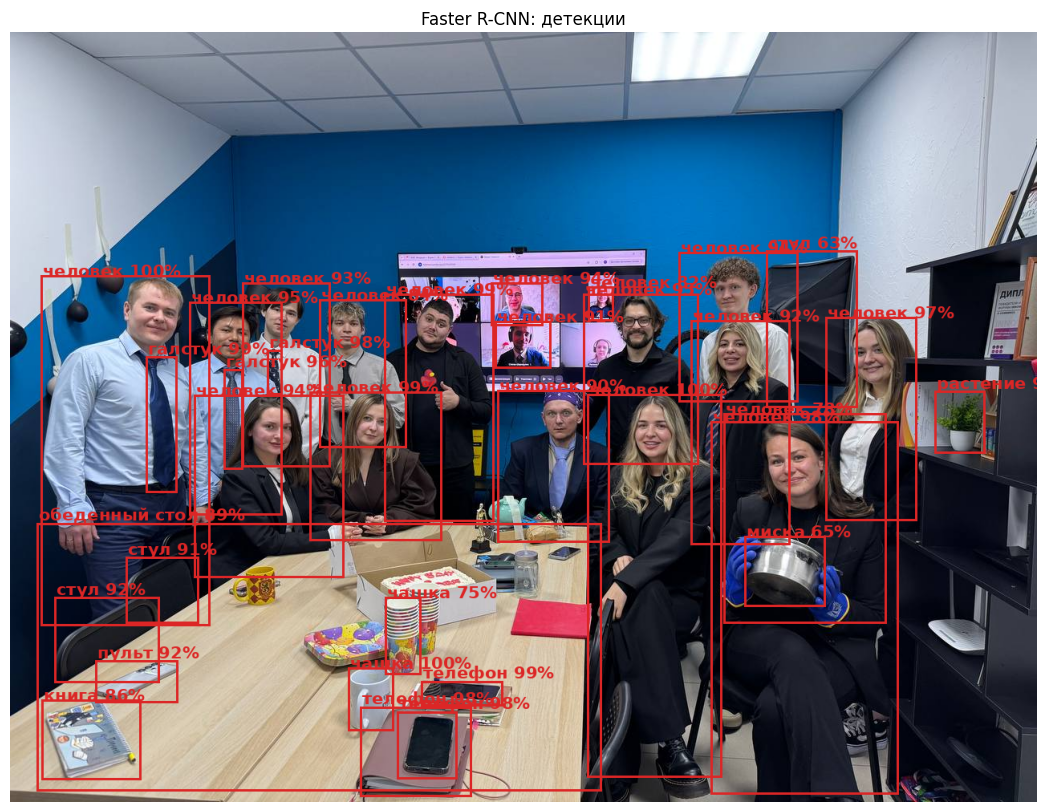

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

with Image.open(image_path) as opened_image:
    source_image = opened_image.convert('RGB')

detections = run_inference(
    model=detector,
    image=source_image,
    label_names=coco_labels,
    score_threshold=0.6,
    device=device,
)
annotated_image = draw_detections(source_image, detections)

output_path = Path('results/lab1_detections.jpg')
output_path.parent.mkdir(exist_ok=True)
annotated_image.save(output_path)

print(f'Найдено объектов: {len(detections)}')
for number, detection in enumerate(detections, start=1):
    print(f'{number}. {detection.label}: {detection.score:.2f}, box={detection.box}')

plt.figure(figsize=(14, 10))
plt.imshow(annotated_image)
plt.axis('off')
plt.title('Faster R-CNN: детекции')
plt.show()


Модель Faster R-CNN, выполнила полный конвейер обработки изображения и визуализации детекций.